In [1]:
#   Copyright 2022 - 2026 The PyMC Labs Developers
#
#   Licensed under the Apache License, Version 2.0 (the "License");
#   you may not use this file except in compliance with the License.
#   You may obtain a copy of the License at
#
#       http://www.apache.org/licenses/LICENSE-2.0
#
#   Unless required by applicable law or agreed to in writing, software
#   distributed under the License is distributed on an "AS IS" BASIS,
#   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#   See the License for the specific language governing permissions and
#   limitations under the License.
"""Comparison of additive, log, and log-log MMM specifications."""
# ---
# jupyter:
#   jupytext:
#     formats: py:percent
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

'Comparison of additive, log, and log-log MMM specifications.'

# Additive vs Log vs Log-Log Media Mix Models

This notebook compares three MMM specifications available through the `link`
parameter on the `MMM` class:

| Model | `link` | Saturation | Likelihood | Interpretation |
|-------|--------|------------|------------|----------------|
| **Additive** | `"identity"` | `LogisticSaturation` | Normal | Components add to $y$ |
| **Log (multiplicative)** | `"log"` | `LogisticSaturation` | LogNormal | Components multiply $y$ via $\exp$ |
| **Log-log (elasticity)** | `"log"` | `LogSaturation` | LogNormal | Coefficients are elasticities |

## Mathematical Formulation

All three models share the same **linear predictor**:

$$\mu = \text{intercept} + \sum_c \text{saturation}_c(\text{adstock}_c(x_c)) + \text{controls} + \text{seasonality}$$

They differ in how $\mu$ relates to the observed target $y$:

### 1. Additive (Identity Link)

$$y_{\text{scaled}} \sim \text{Normal}(\mu, \sigma)$$

Each component of $\mu$ contributes additively to $y$. This is the standard
formulation used in most MMM literature.

### 2. Log (Multiplicative)

$$y_{\text{scaled}} \sim \text{LogNormal}(\mu, \sigma)$$

Equivalently, $\log(y_{\text{scaled}}) \sim \text{Normal}(\mu, \sigma)$, so
$y \propto \exp(\mu)$. Each additive component in $\mu$ becomes a
**multiplicative factor** on $y$:

$$y = \exp(\text{intercept}) \times \prod_c \exp(\text{saturation}_c) \times \exp(\text{controls}) \times \ldots$$

Use this when the data-generating process is multiplicative (e.g. sales =
baseline $\times$ media uplift $\times$ seasonality).

### 3. Log-Log (Elasticity)

Same as the log model, but the saturation function is $\beta \log(1 + x)$
(`LogSaturation`) instead of a sigmoidal curve. The coefficient $\beta$ has
an **elasticity-like** interpretation: approximately the % change in $y$ per
1% change in spend.

Use this when channel response follows a power-law / constant-elasticity
relationship and you want directly interpretable media coefficients.

## Trend Handling

A raw integer trend $t = 0, 1, \ldots, n$ behaves differently depending on the
link function:

- **Identity link**: $\gamma_t \cdot t$ adds a **linear** trend to $y$.
- **Log link**: $\gamma_t \cdot t$ in log-space gives **exponential** growth
  $y \propto \exp(\gamma_t \cdot t)$.

With the quickstart's prior $\gamma \sim N(0, 0.05)$ and $t$ up to ~200,
the log-space contribution could reach $\exp(10) \approx 22{,}000\times$ —
completely degenerate. To avoid this, we **normalize the trend to $[0, 1]$**
for the log and log-log models, so $\gamma_t$ directly represents the total
multiplicative trend factor via $\exp(\gamma_t)$.

## Setup

In [2]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation, LogSaturation
from pymc_marketing.mmm.multidimensional import MMM

warnings.filterwarnings("ignore")

az.style.use("arviz-darkgrid")

seed = sum(map(ord, "mmm"))
rng = np.random.default_rng(seed=seed)

CHANNELS = ["x1", "x2"]
CONTROL_COLUMNS_ADDITIVE = ["event_1", "event_2", "t"]
CONTROL_COLUMNS_LOG = ["event_1", "event_2", "t_norm"]

SAMPLER_CONFIG = {"progressbar": True}

/Users/juanitorduz/micromamba/envs/pymc-marketing-dev/lib/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Data Loading and Preparation

In [3]:
url = "https://raw.githubusercontent.com/pymc-labs/pymc-marketing/main/data/mmm_example.csv"
data = pd.read_csv(url, parse_dates=["date_week"])
data.head()

,date_week,y,x1,x2,event_1,event_2,dayofyear,t
0,2018-04-02,3984.662237,0.318580,0.0,0.0,0.0,92,0
1,2018-04-09,3762.871794,0.112388,0.0,0.0,0.0,99,1
2,2018-04-16,4466.967388,0.292400,0.0,0.0,0.0,106,2
3,2018-04-23,3864.219373,0.071399,0.0,0.0,0.0,113,3
4,2018-04-30,4441.625278,0.386745,0.0,0.0,0.0,120,4


In [4]:
# Raw integer trend (for the additive model, matching the quickstart)
data["t"] = range(len(data))

# Normalized trend in [0, 1] (for log/log-log models, avoids exponential blow-up)
data["t_norm"] = data["t"] / data["t"].max()

y = data["y"]

# Two versions of X: one per link type
X_additive = data.drop(columns=["y"])
X_log = data.drop(columns=["y", "t"]).copy()

print(f"Observations: {len(data)}")
print(f"Target range: [{y.min():.1f}, {y.max():.1f}]")
print(f"All y > 0: {(y > 0).all()}  (required for log link)")

Observations: 179
Target range: [3192.9, 8312.4]
All y > 0: True  (required for log link)


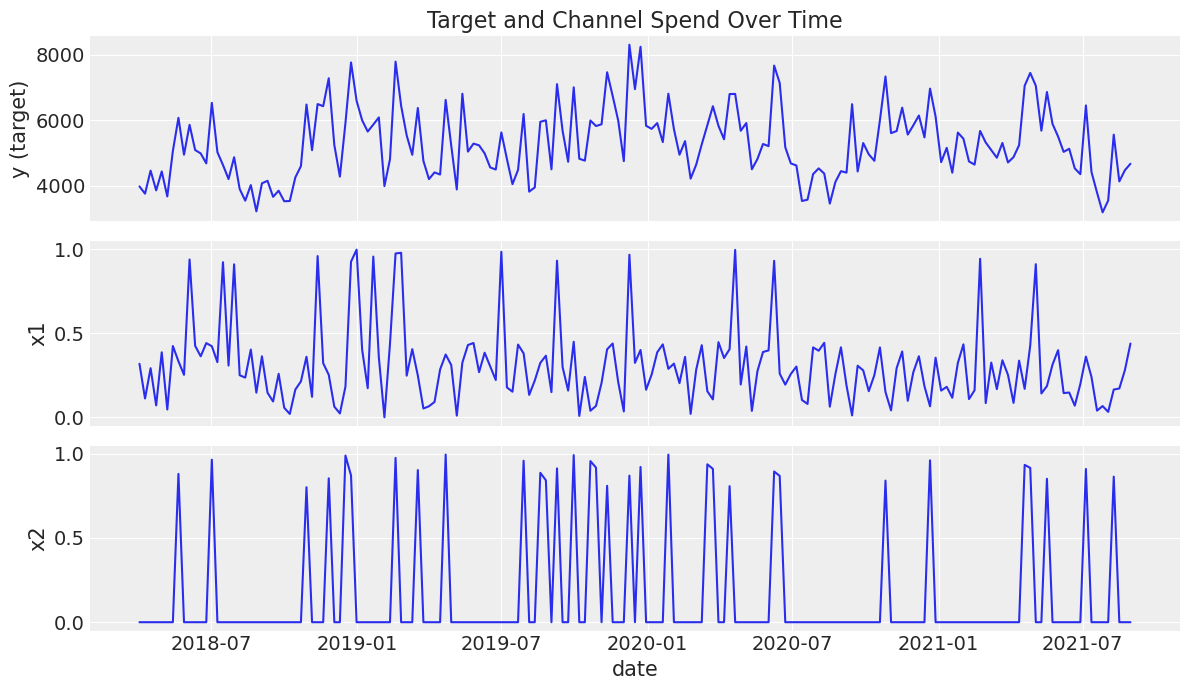

In [5]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 7), sharex=True)

axes[0].plot(data["date_week"], y)
axes[0].set(ylabel="y (target)", title="Target and Channel Spend Over Time")

for i, ch in enumerate(CHANNELS):
    axes[i + 1].plot(data["date_week"], data[ch], label=ch)
    axes[i + 1].set(ylabel=ch)

axes[-1].set(xlabel="date")
fig.tight_layout()
plt.show()

## Spend Shares and Prior Configuration

In [6]:
total_spend_per_channel = data[CHANNELS].sum(axis=0)
spend_share = total_spend_per_channel / total_spend_per_channel.sum()
n_channels = len(CHANNELS)
prior_sigma = n_channels * spend_share.to_numpy()

print("Spend share:", spend_share.to_dict())
print("Prior sigma for saturation_beta:", prior_sigma)

Spend share: {'x1': 0.6563195134700339, 'x2': 0.34368048652996613}
Prior sigma for saturation_beta: [1.31263903 0.68736097]


In [7]:
# --- Additive model config (from quickstart) ---
additive_model_config = {
    "intercept": Prior("Normal", mu=0.5, sigma=0.2),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.05, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=6), dims="date"),
}

# --- Log / log-log model config ---
# The link="log" defaults handle intercept (Normal(0, 5)) and likelihood
# (LogNormal(sigma=HalfNormal(0.5))). We override saturation_beta,
# gamma_control (wider for [0,1]-scaled trend), and gamma_fourier.
log_model_config = {
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
}

## Helper Functions

In [8]:
VAR_NAMES_TRACE = ["saturation_beta", "adstock_alpha"]


def check_divergences(mmm, model_name):
    """Print divergence count for a fitted model."""
    n_div = mmm.idata["sample_stats"]["diverging"].sum().item()
    print(f"[{model_name}] Divergences: {n_div}")
    if n_div > 0:
        print("  -> Consider raising target_accept or reparameterizing.")
    return n_div


def plot_trace(mmm, model_name, var_names=VAR_NAMES_TRACE):
    """Plot trace for key media parameters."""
    az.plot_trace(
        data=mmm.fit_result,
        var_names=var_names,
        compact=True,
        backend_kwargs={"figsize": (10, 2 * len(var_names)), "layout": "constrained"},
    )
    plt.suptitle(f"Trace Plot — {model_name}", y=1.02)
    plt.show()


def plot_posterior_predictive_additive(mmm, y_obs, model_name):
    """Plot posterior predictive for an additive (identity-link) model."""
    mmm.sample_posterior_predictive(mmm.X, extend_idata=True, combined=True)
    y_hat = mmm.idata.posterior_predictive["y"].stack(sample=("chain", "draw")).values
    target_scale = mmm.idata.constant_data["target_scale"].item()
    y_hat_original = y_hat * target_scale

    fig, ax = plt.subplots(figsize=(12, 4))
    dates = mmm.X["date_week"]
    ax.plot(dates, y_obs.values, color="black", label="observed")
    mean = y_hat_original.mean(axis=-1)
    ax.plot(dates, mean, color="C0", label="posterior mean")
    for hdi_prob, alpha in [(0.94, 0.15), (0.5, 0.3)]:
        hdi = az.hdi(y_hat_original.T, hdi_prob=hdi_prob)
        ax.fill_between(dates, hdi[:, 0], hdi[:, 1], color="C0", alpha=alpha)
    ax.set(title=f"Posterior Predictive — {model_name}", xlabel="date", ylabel="y")
    ax.legend()
    fig.tight_layout()
    plt.show()
    return mean


def plot_posterior_predictive_log(mmm, y_obs, model_name):
    """Plot posterior predictive for a log-link model using y_hat_original_scale."""
    y_hat_orig = mmm.idata.posterior["y_hat_original_scale"]
    y_hat_flat = y_hat_orig.stack(sample=("chain", "draw")).values

    fig, ax = plt.subplots(figsize=(12, 4))
    dates = mmm.X["date_week"]
    ax.plot(dates, y_obs.values, color="black", label="observed")
    mean = y_hat_flat.mean(axis=-1)
    ax.plot(dates, mean, color="C1", label="posterior mean")
    for hdi_prob, alpha in [(0.94, 0.15), (0.5, 0.3)]:
        hdi = az.hdi(y_hat_flat.T, hdi_prob=hdi_prob)
        ax.fill_between(dates, hdi[:, 0], hdi[:, 1], color="C1", alpha=alpha)
    ax.set(title=f"Posterior Predictive — {model_name}", xlabel="date", ylabel="y")
    ax.legend()
    fig.tight_layout()
    plt.show()
    return mean


def plot_decomposition(contributions_df, model_name, date_col="date"):
    """Plot stacked contribution bar chart from compute_mean_contributions_over_time."""
    component_cols = [c for c in contributions_df.columns if c != date_col]
    fig, ax = plt.subplots(figsize=(12, 4))
    contributions_df.plot.area(
        x=date_col, y=component_cols, ax=ax, alpha=0.7, linewidth=0.5
    )
    ax.set(
        title=f"Decomposition — {model_name}",
        xlabel="date",
        ylabel="contribution (original scale)",
    )
    ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    plt.show()

---
# Model 1: Additive (Identity Link)

This is the standard additive MMM from the quickstart notebook. The linear
predictor $\mu$ maps directly to the expected value of $y$ via the identity
link and a Normal likelihood.

In [9]:
mmm_additive = MMM(
    model_config=additive_model_config,
    sampler_config=SAMPLER_CONFIG,
    date_column="date_week",
    channel_columns=CHANNELS,
    control_columns=CONTROL_COLUMNS_ADDITIVE,
    yearly_seasonality=2,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    link="identity",
)

mmm_additive.build_model(X_additive, y)
mmm_additive.add_original_scale_contribution_variable(
    [
        "intercept_contribution",
        "control_contribution",
        "channel_contribution",
        "fourier_contribution",
        "yearly_seasonality_contribution",
    ]
)
mmm_additive.table()

                                         Variable  Expression                 Dimensions                  
──────────────────────────────────────────────────────────────────────────────────────────────────────────
                                  channel_scale =  Data                       channel[2]                  
                                   target_scale =  Data                                                   
                                   channel_data =  Data                       date[179] × channel[2]      
                                    target_data =  Data                       date[179]                   
                                   control_data =  Data                       date[179] × control[3]      
                                      dayofyear =  Data                       date[179]                   
                                                                                                          
                         intercept_contribution ~  Normal(0.5, 0.2)                                       
                                  adstock_alpha ~  Beta(2, 1, 3)              channel[2]                  
                                 saturation_lam ~  Gamma(2, 3, f())           channel[2]                  
                                saturation_beta ~  HalfNormal(0, <constant>)  channel[2]                  
                                  gamma_control ~  Normal(3, 0, 0.05)         control[3]                  
                                  gamma_fourier ~  Laplace(4, 0, 0.2)         fourier_mode[4]             
                                        y_sigma ~  HalfNormal(0, 6)                                       
                                                                              Parameter count = 15        
                                                                                                          
                           channel_contribution =  f()                        date[179] × channel[2]      
                           control_contribution =  f()                        date[179] × control[3]      
                           fourier_contribution =  f()                        date[179] × fourier_mode[4] 
                yearly_seasonality_contribution =  f()                        date[179]                   
        total_media_contribution_original_scale =  f()                                                    
          intercept_contribution_original_scale =  f()                                                    
            control_contribution_original_scale =  f()                        date[179] × control[3]      
            channel_contribution_original_scale =  f()                        date[179] × channel[2]      
            fourier_contribution_original_scale =  f()                        date[179] × fourier_mode[4] 
 yearly_seasonality_contribution_original_scale =  f()                        date[179]                   
                                                                                                          
                                              y ~  Normal(f(), f())           date[179]

In [10]:
_ = mmm_additive.fit(
    X=X_additive,
    y=y,
    chains=4,
    target_accept=0.85,
    nuts_sampler="nutpie",
    random_seed=rng,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.26,15
,2000,0,0.27,31
,2000,0,0.25,63
,2000,0,0.23,31


Output()

[Additive] Divergences: 0


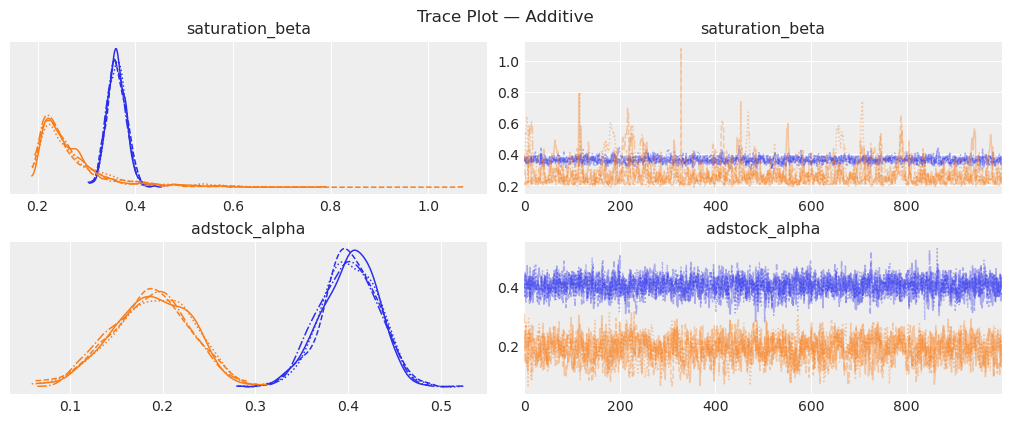

In [11]:
check_divergences(mmm_additive, "Additive")
plot_trace(mmm_additive, "Additive")

Sampling: [y]


Output()

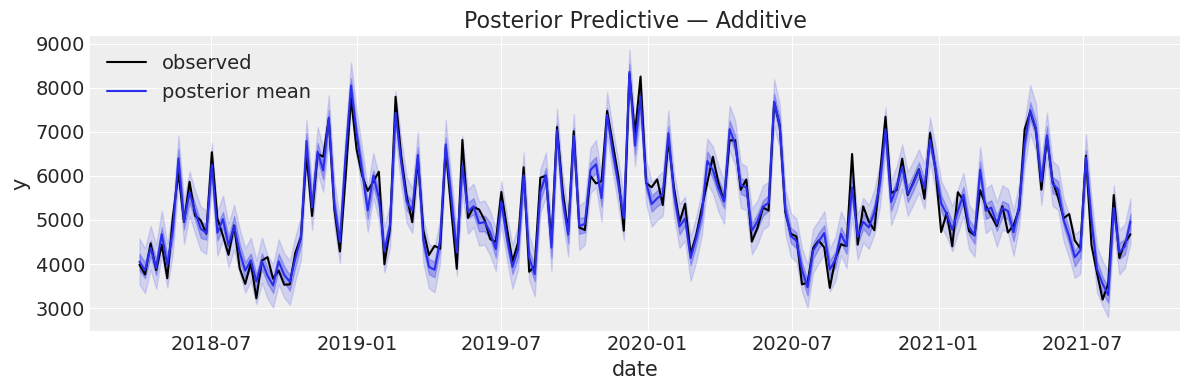

In [12]:
y_hat_additive = plot_posterior_predictive_additive(mmm_additive, y, "Additive")

In [13]:
contributions_additive = mmm_additive.compute_mean_contributions_over_time()
contributions_additive.head()

,date,target_scale_dim_0,x1,x2,event_1,event_2,t,yearly_seasonality,intercept
0,2018-04-02,0,1085.298875,0.0,0.0,0.0,0.000000,21.560168,2944.235402
1,2018-04-09,0,834.763675,0.0,0.0,0.0,5.138386,73.739778,2944.235402
2,2018-04-16,0,1296.394969,0.0,0.0,0.0,10.276772,119.703160,2944.235402
3,2018-04-23,0,793.620648,0.0,0.0,0.0,15.415158,154.129556,2944.235402
4,2018-04-30,0,1543.001291,0.0,0.0,0.0,20.553544,172.431160,2944.235402


ValueError: When stacked is True, each column must be either all positive or all negative. Column 'yearly_seasonality' contains both positive and negative values

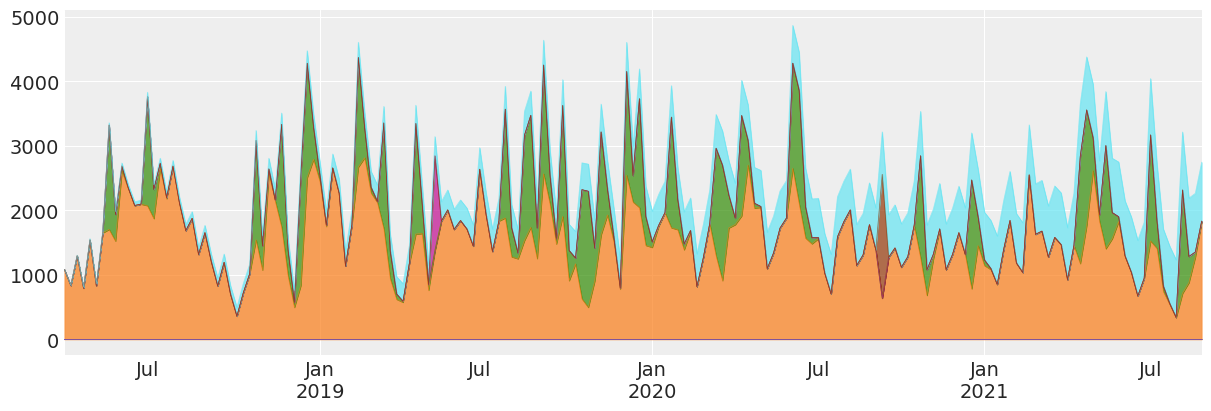

In [14]:
plot_decomposition(contributions_additive, "Additive")

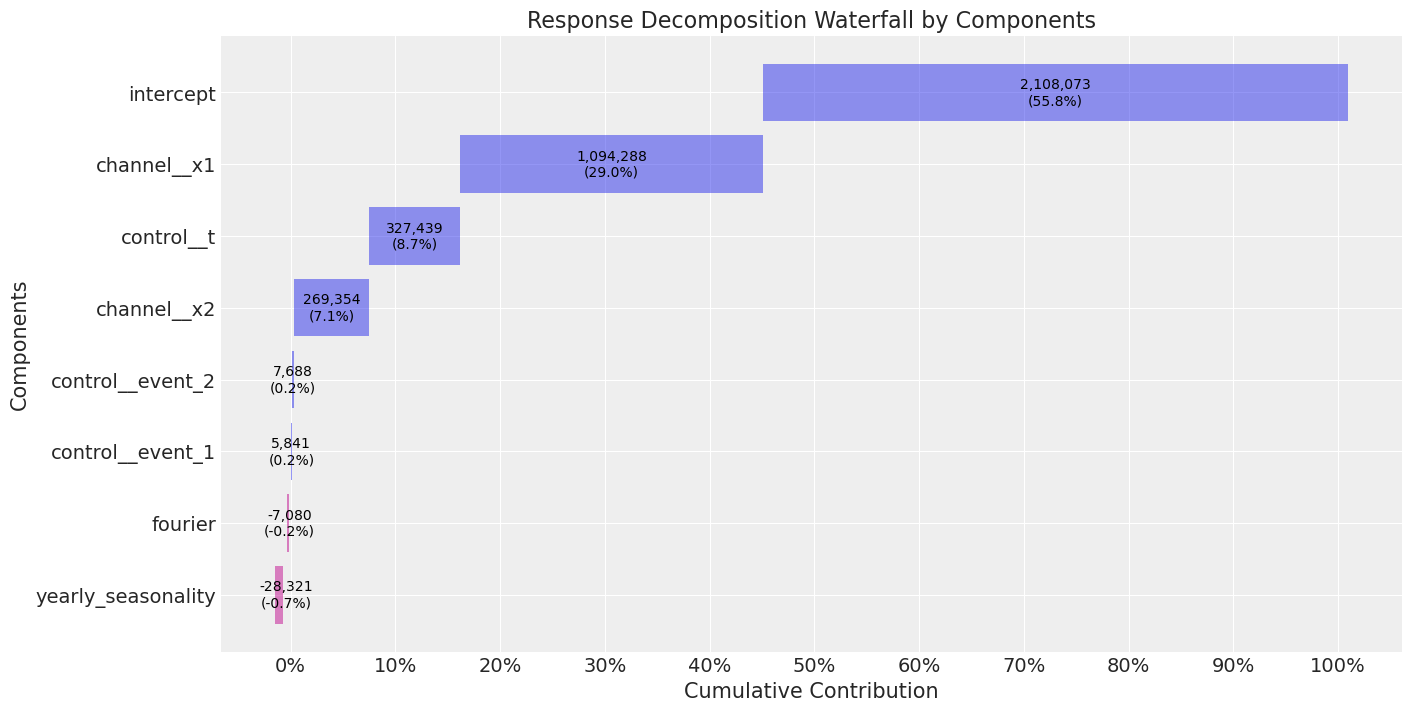

In [15]:
mmm_additive.plot.waterfall_components_decomposition(original_scale=True)
plt.show()

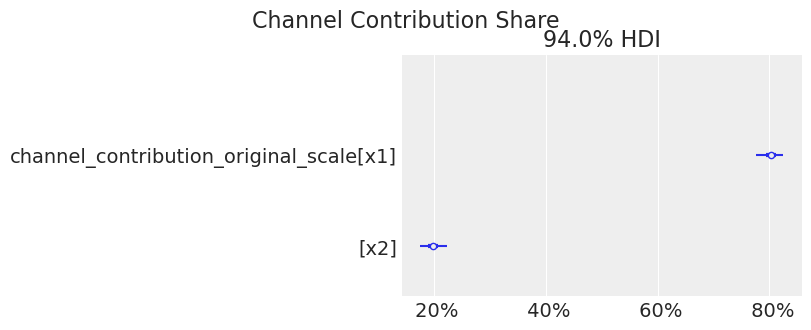

In [16]:
mmm_additive.plot.channel_contribution_share_hdi(figsize=(8, 3))
plt.show()

---
# Model 2: Log (Multiplicative)

With `link="log"`, the linear predictor $\mu$ is the same additive
combination, but each component becomes a **multiplicative factor** on $y$
via $\exp(\cdot)$:

$$y = \exp(\text{intercept}) \times \prod_c \exp(\text{saturation}_c(\text{adstock}_c(x_c))) \times \ldots$$

The likelihood is `LogNormal`, so $\log(y_{\text{scaled}}) \sim N(\mu, \sigma)$.

**Note on trend**: We use `t_norm` (normalized to $[0, 1]$) instead of the
raw integer `t` to avoid exponential blow-up. The coefficient $\gamma_t$ now
represents the total log-scale trend over the observation period, and
$\exp(\gamma_t)$ is the multiplicative factor from start to end.

**Note on contributions**: `add_original_scale_contribution_variable` raises
a `ValueError` under `link="log"` because simple multiplication by
`target_scale` is incorrect in log-space. We use
`compute_mean_contributions_over_time()` instead, which applies the correct
counterfactual hybrid decomposition.

In [17]:
mmm_log = MMM(
    model_config=log_model_config,
    sampler_config=SAMPLER_CONFIG,
    date_column="date_week",
    channel_columns=CHANNELS,
    control_columns=CONTROL_COLUMNS_LOG,
    yearly_seasonality=2,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    link="log",
)

mmm_log.build_model(X_log, y)
mmm_log.table()

                                  Variable  Expression                 Dimensions                  
───────────────────────────────────────────────────────────────────────────────────────────────────
                           channel_scale =  Data                       channel[2]                  
                            target_scale =  Data                                                   
                            channel_data =  Data                       date[179] × channel[2]      
                             target_data =  Data                       date[179]                   
                            control_data =  Data                       date[179] × control[3]      
                               dayofyear =  Data                       date[179]                   
                                                                                                   
                  intercept_contribution ~  Normal(0, 5)                                           
                           adstock_alpha ~  Beta(2, 1, 3)              channel[2]                  
                          saturation_lam ~  Gamma(2, 3, f())           channel[2]                  
                         saturation_beta ~  HalfNormal(0, <constant>)  channel[2]                  
                           gamma_control ~  Normal(3, 0, 0.5)          control[3]                  
                           gamma_fourier ~  Laplace(4, 0, 0.2)         fourier_mode[4]             
                                 y_sigma ~  HalfNormal(0, 0.5)                                     
                                                                       Parameter count = 15        
                                                                                                   
                    channel_contribution =  f()                        date[179] × channel[2]      
                    control_contribution =  f()                        date[179] × control[3]      
                    fourier_contribution =  f()                        date[179] × fourier_mode[4] 
         yearly_seasonality_contribution =  f()                        date[179]                   
                                      mu =  f()                        date[179]                   
 total_media_contribution_original_scale =  f()                                                    
                    y_hat_original_scale =  f()                        date[179]                   
                                                                                                   
                                       y ~  LogNormal(mu, f())         date[179]

In [18]:
_ = mmm_log.fit(
    X=X_log,
    y=y,
    chains=4,
    target_accept=0.85,
    nuts_sampler="nutpie",
    random_seed=rng,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.28,31
,2000,0,0.30,15
,2000,0,0.30,15
,2000,0,0.29,15


Output()

[Log (Multiplicative)] Divergences: 0


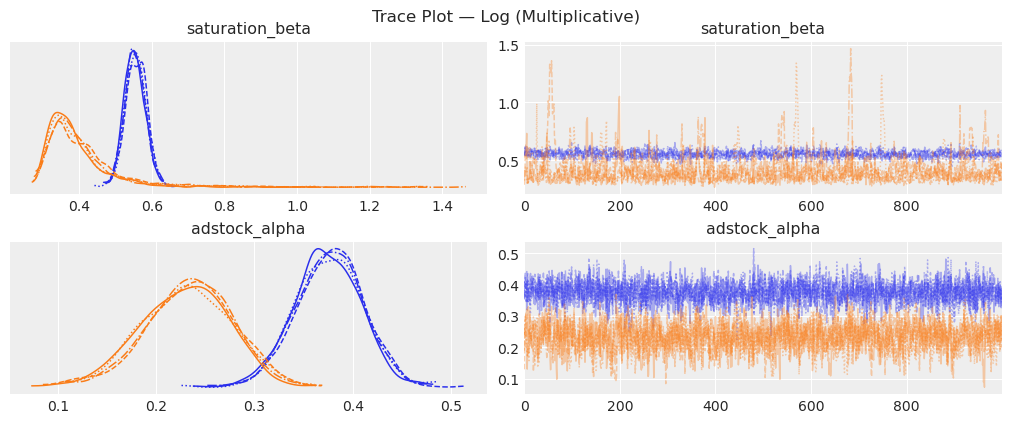

In [19]:
check_divergences(mmm_log, "Log (Multiplicative)")
plot_trace(mmm_log, "Log (Multiplicative)")

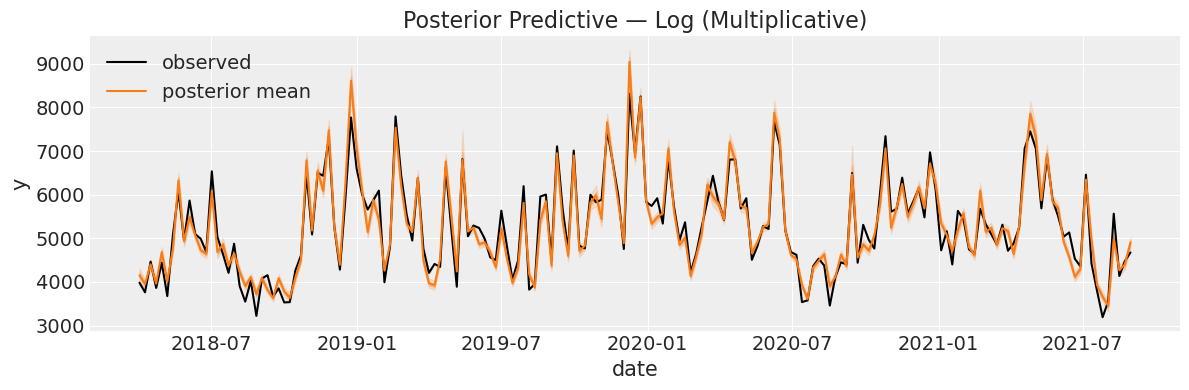

In [20]:
y_hat_log = plot_posterior_predictive_log(mmm_log, y, "Log (Multiplicative)")

In [21]:
contributions_log = mmm_log.compute_mean_contributions_over_time()
contributions_log.head()

,date,target_scale_dim_0,x1,x2,non_media
0,2018-04-02,0,906.936331,0.0,3245.047940
1,2018-04-09,0,668.417774,0.0,3279.895205
2,2018-04-16,0,1093.698792,0.0,3311.192617
3,2018-04-23,0,627.011396,0.0,3335.415323
4,2018-04-30,0,1333.782221,0.0,3349.431910


The log-link decomposition returns per-channel contributions (allocated from
the total counterfactual media lift) plus a `non_media` column that captures
the baseline (intercept + controls + seasonality) in original scale.

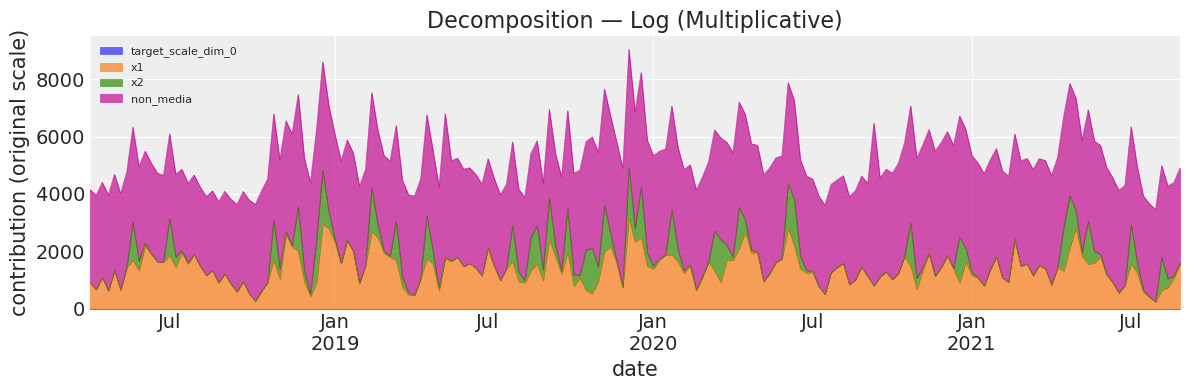

In [22]:
plot_decomposition(contributions_log, "Log (Multiplicative)")

---
# Model 3: Log-Log (Elasticity)

The log-log model combines `link="log"` with `LogSaturation`, which applies
$\beta \log(1 + x)$ instead of a sigmoidal curve. This gives the model a
constant-elasticity structure:

$$\log(y) \sim \ldots + \beta_c \log(1 + \text{adstock}_c(x_c)) + \ldots$$

The coefficient $\beta_c$ approximates the **elasticity**: the percentage
change in $y$ for a 1% change in spend on channel $c$. This is directly
interpretable for marketing decision-making.

**Note**: Under the default scaling pipeline, channel data is divided by
`channel_scale`, so these are approximate elasticities with respect to
*scaled* spend rather than strict textbook elasticities.

In [23]:
mmm_loglog = MMM(
    model_config=log_model_config,
    sampler_config=SAMPLER_CONFIG,
    date_column="date_week",
    channel_columns=CHANNELS,
    control_columns=CONTROL_COLUMNS_LOG,
    yearly_seasonality=2,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogSaturation(),
    link="log",
)

mmm_loglog.build_model(X_log, y)
mmm_loglog.table()

                                  Variable  Expression                 Dimensions                  
───────────────────────────────────────────────────────────────────────────────────────────────────
                           channel_scale =  Data                       channel[2]                  
                            target_scale =  Data                                                   
                            channel_data =  Data                       date[179] × channel[2]      
                             target_data =  Data                       date[179]                   
                            control_data =  Data                       date[179] × control[3]      
                               dayofyear =  Data                       date[179]                   
                                                                                                   
                  intercept_contribution ~  Normal(0, 5)                                           
                           adstock_alpha ~  Beta(2, 1, 3)              channel[2]                  
                         saturation_beta ~  HalfNormal(0, <constant>)  channel[2]                  
                           gamma_control ~  Normal(3, 0, 0.5)          control[3]                  
                           gamma_fourier ~  Laplace(4, 0, 0.2)         fourier_mode[4]             
                                 y_sigma ~  HalfNormal(0, 0.5)                                     
                                                                       Parameter count = 13        
                                                                                                   
                    channel_contribution =  f()                        date[179] × channel[2]      
                    control_contribution =  f()                        date[179] × control[3]      
                    fourier_contribution =  f()                        date[179] × fourier_mode[4] 
         yearly_seasonality_contribution =  f()                        date[179]                   
                                      mu =  f()                        date[179]                   
 total_media_contribution_original_scale =  f()                                                    
                    y_hat_original_scale =  f()                        date[179]                   
                                                                                                   
                                       y ~  LogNormal(mu, f())         date[179]

In [24]:
_ = mmm_loglog.fit(
    X=X_log,
    y=y,
    chains=4,
    target_accept=0.85,
    nuts_sampler="nutpie",
    random_seed=rng,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.41,15
,2000,0,0.40,15
,2000,0,0.41,7
,2000,0,0.38,15


Output()

KeyError: "Type 'pymc_marketing.mmm.components.saturation.LogSaturation' is not registered in the TypeRegistry. Use @serialization.register to register it."

[Log-Log (Elasticity)] Divergences: 0


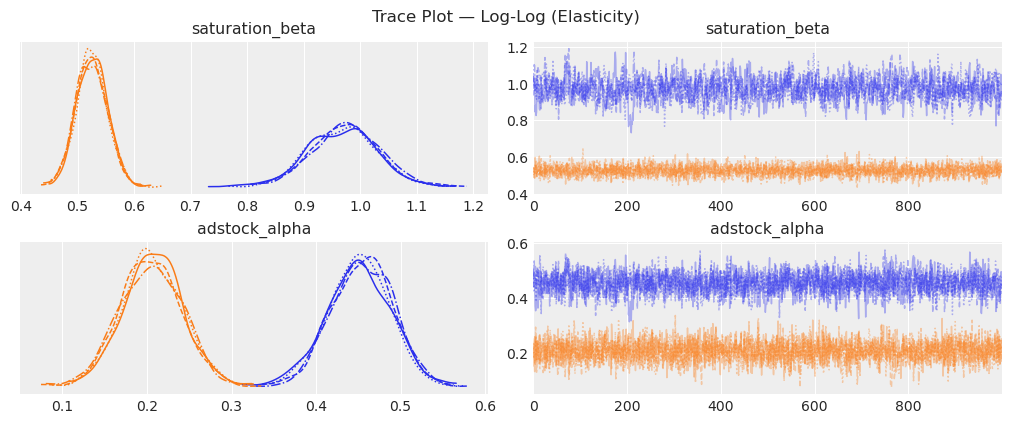

In [25]:
check_divergences(mmm_loglog, "Log-Log (Elasticity)")
plot_trace(
    mmm_loglog, "Log-Log (Elasticity)", var_names=["saturation_beta", "adstock_alpha"]
)

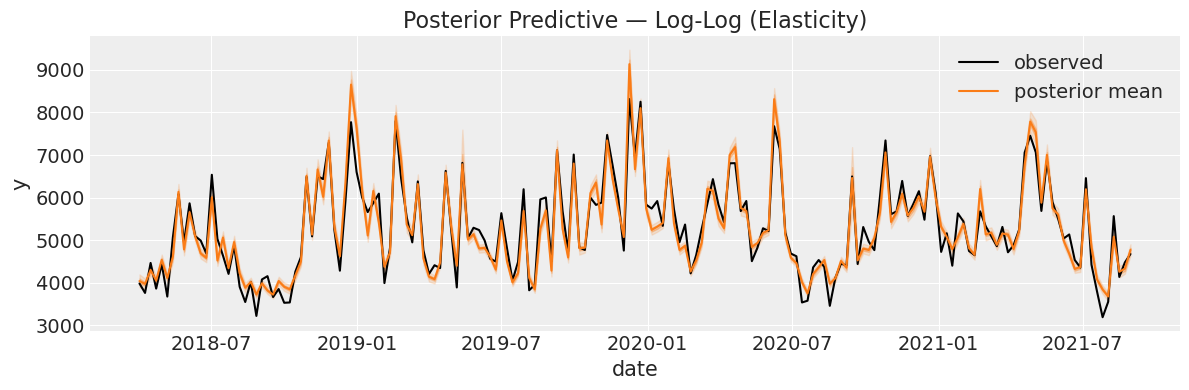

In [26]:
y_hat_loglog = plot_posterior_predictive_log(mmm_loglog, y, "Log-Log (Elasticity)")

In [27]:
contributions_loglog = mmm_loglog.compute_mean_contributions_over_time()
contributions_loglog.head()

,date,target_scale_dim_0,x1,x2,non_media
0,2018-04-02,0,585.272607,0.0,3455.933100
1,2018-04-09,0,476.602174,0.0,3498.050321
2,2018-04-16,0,767.336838,0.0,3535.878709
3,2018-04-23,0,486.021708,0.0,3565.439571
4,2018-04-30,0,957.437105,0.0,3583.208046


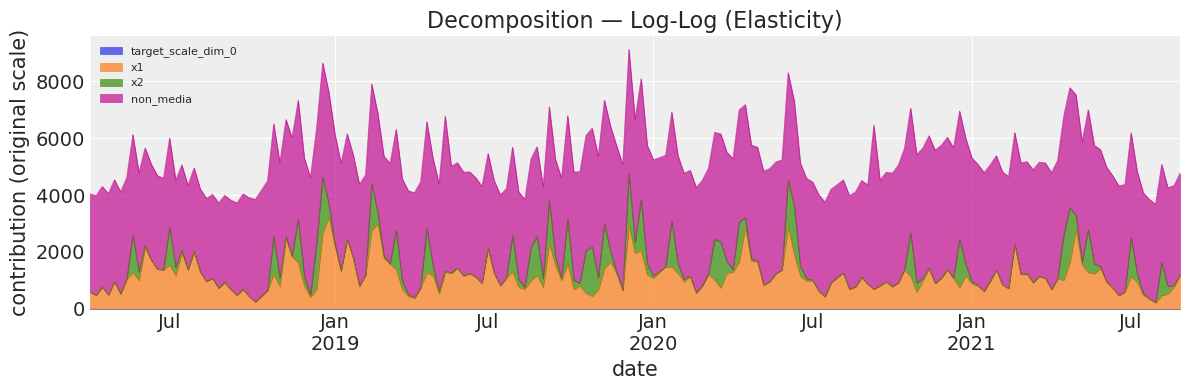

In [28]:
plot_decomposition(contributions_loglog, "Log-Log (Elasticity)")

---
# Comparison

## Posterior Predictive Fit

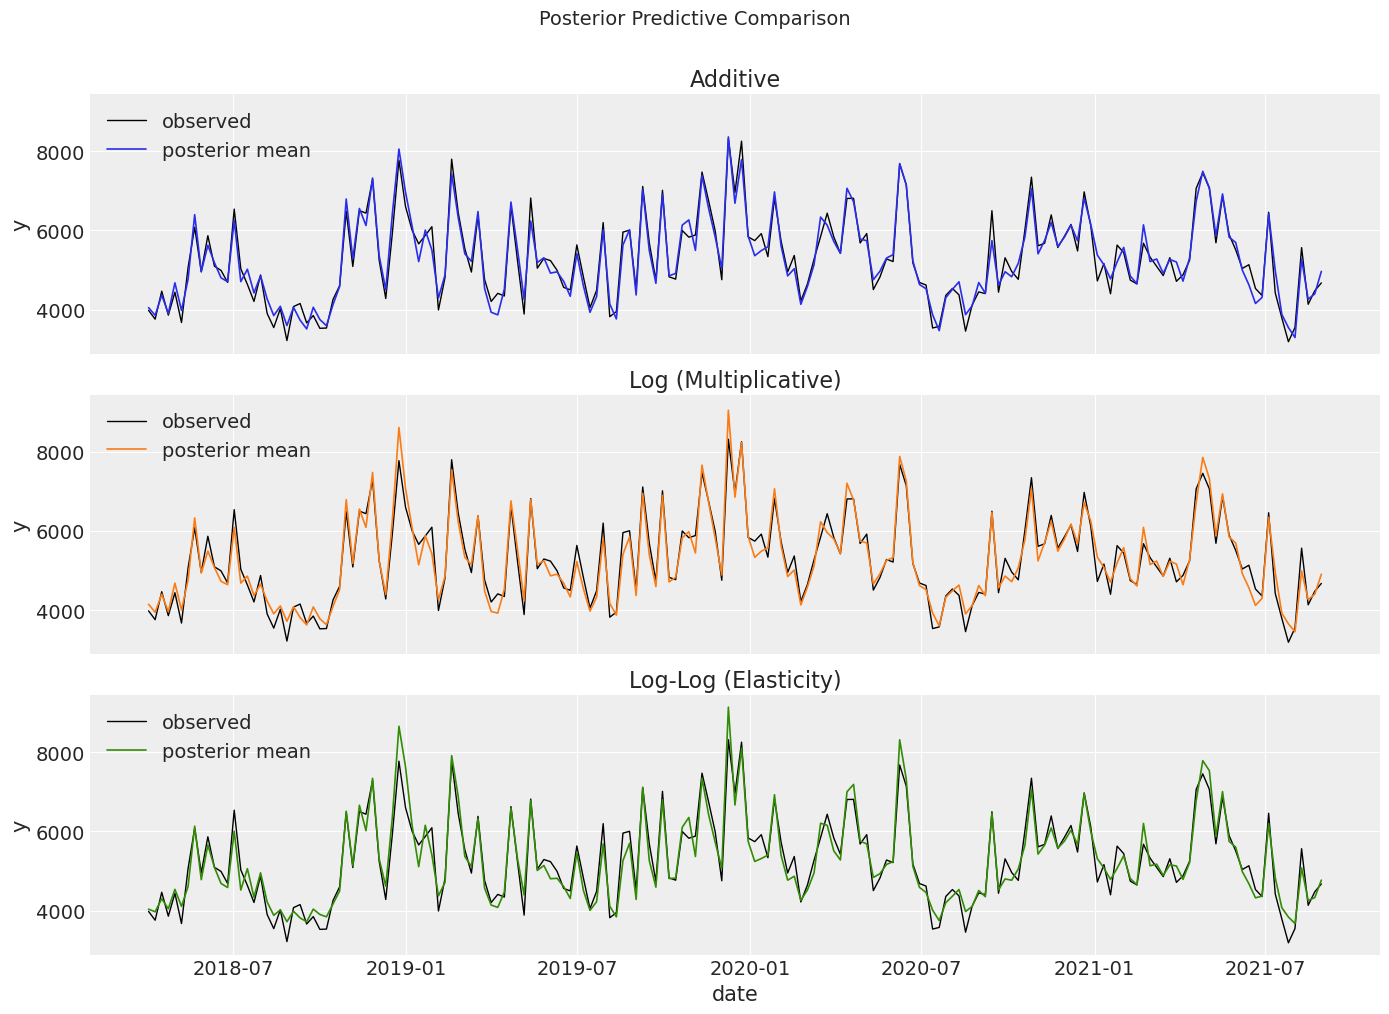

In [29]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True, sharey=True)
dates = data["date_week"]
models = [
    ("Additive", y_hat_additive, "C0"),
    ("Log (Multiplicative)", y_hat_log, "C1"),
    ("Log-Log (Elasticity)", y_hat_loglog, "C2"),
]
for ax, (name, y_hat, color) in zip(axes, models, strict=True):
    ax.plot(dates, y.values, color="black", linewidth=1, label="observed")
    ax.plot(dates, y_hat, color=color, linewidth=1.2, label="posterior mean")
    ax.set(ylabel="y", title=name)
    ax.legend(loc="upper left")

axes[-1].set(xlabel="date")
fig.suptitle("Posterior Predictive Comparison", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## Decomposition Comparison

The additive model decomposes $y$ into intercept + channels + controls +
seasonality. The log models use a hybrid counterfactual decomposition:
per-channel contributions are allocated from the total media lift, and the
residual is reported as `non_media` (absorbing intercept, controls, and
seasonality).

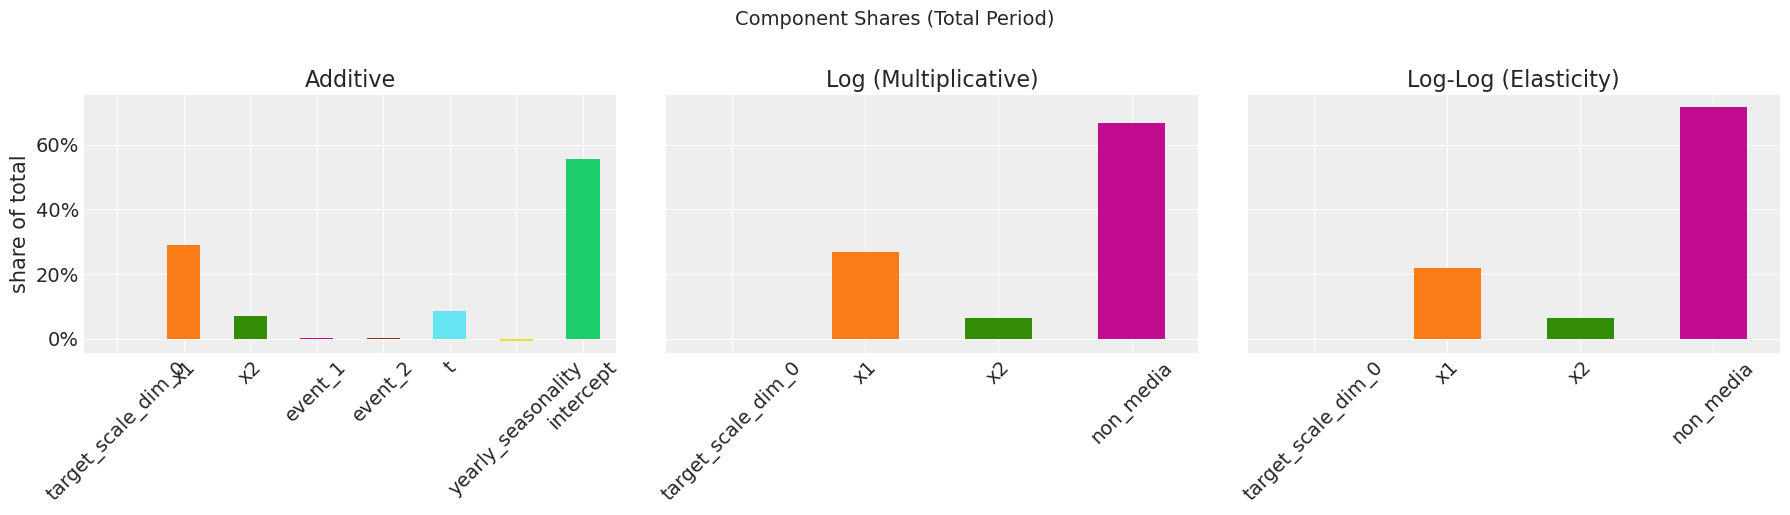

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), sharey=True)
decomp_data = [
    ("Additive", contributions_additive),
    ("Log (Multiplicative)", contributions_log),
    ("Log-Log (Elasticity)", contributions_loglog),
]
for ax, (name, df) in zip(axes, decomp_data, strict=True):
    date_col = next(c for c in ("date", "date_week") if c in df.columns)
    component_cols = [c for c in df.columns if c != date_col]
    total = df[component_cols].sum()
    total_sum = total.sum()
    shares = total / total_sum
    shares.plot.bar(ax=ax, color=[f"C{i}" for i in range(len(shares))])
    ax.set(title=name, xlabel="", ylabel="share of total" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Component Shares (Total Period)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## Channel Contribution Shares

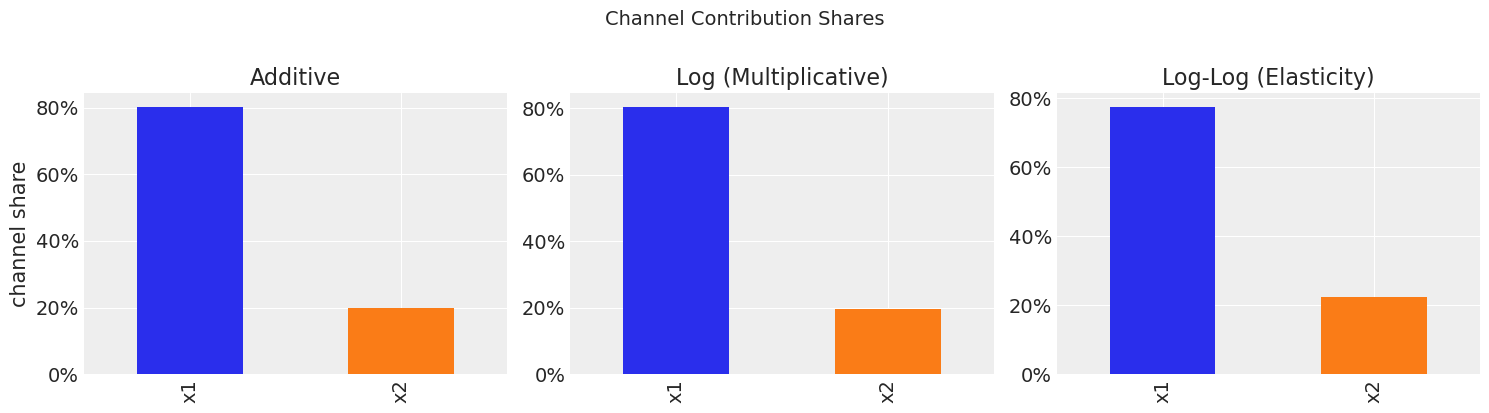

In [31]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
for ax, (name, df) in zip(axes, decomp_data, strict=True):
    channel_cols = [c for c in CHANNELS if c in df.columns]
    if channel_cols:
        channel_total = df[channel_cols].sum()
        channel_share = channel_total / channel_total.sum()
        channel_share.plot.bar(ax=ax, color=["C0", "C1"])
    ax.set(title=name, xlabel="", ylabel="channel share" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

fig.suptitle("Channel Contribution Shares", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## Adstock Parameter Comparison

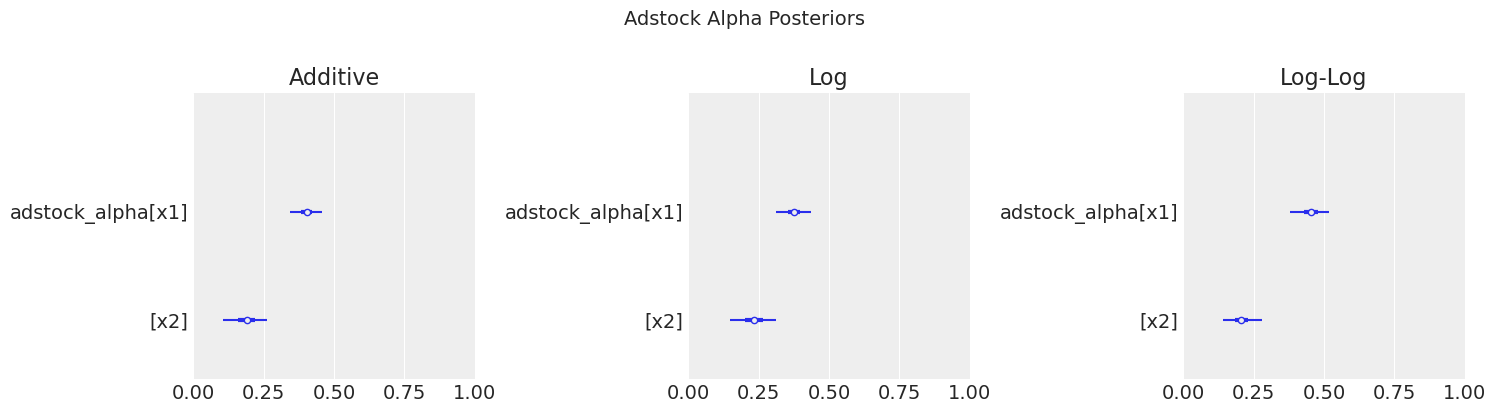

In [32]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
for ax, (name, mmm) in zip(
    axes,
    [("Additive", mmm_additive), ("Log", mmm_log), ("Log-Log", mmm_loglog)],
    strict=True,
):
    az.plot_forest(
        mmm.fit_result,
        var_names=["adstock_alpha"],
        combined=True,
        ax=ax,
        hdi_prob=0.94,
    )
    ax.set(title=name, xlim=(0, 1))

fig.suptitle("Adstock Alpha Posteriors", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## Summary Metrics

In [33]:
results = []
for name, mmm_obj, y_hat in [
    ("Additive", mmm_additive, y_hat_additive),
    ("Log (Multiplicative)", mmm_log, y_hat_log),
    ("Log-Log (Elasticity)", mmm_loglog, y_hat_loglog),
]:
    n_div = mmm_obj.idata["sample_stats"]["diverging"].sum().item()
    residuals = y.values - y_hat
    mae = np.abs(residuals).mean()
    rmse = np.sqrt((residuals**2).mean())
    mape = np.abs(residuals / y.values).mean() * 100

    results.append(
        {
            "Model": name,
            "Divergences": int(n_div),
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "MAPE (%)": round(mape, 2),
        }
    )

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

               Model  Divergences    MAE   RMSE  MAPE (%)
            Additive            0 196.96 249.02      3.90
Log (Multiplicative)            0 207.45 264.36      4.05
Log-Log (Elasticity)            0 236.08 303.99      4.59


**Caveat on model comparison**: The additive model uses a Normal likelihood
while the log models use LogNormal. This means LOO/WAIC scores are on
different scales and **not directly comparable**. The metrics above
(MAE, RMSE, MAPE) compare posterior predictive means in original scale,
providing a qualitative sense of fit quality. For formal model selection
between link functions, consider predictive checks on held-out data or
domain-driven criteria (e.g. does the DGP look multiplicative?).

---

In [34]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pymc,nutpie

Last updated: Thu, 02 Apr 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.11.0

pymc_marketing: 0.19.2
pymc          : 5.28.1
nutpie        : 0.16.8

arviz         : 0.23.4
matplotlib    : 3.10.8
numpy         : 2.4.2
pandas        : 2.3.3
pymc_extras   : 0.9.3
pymc_marketing: 0.19.2

Watermark: 2.6.0

